In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path(r"D:\Documents\MBA\IIP Skills updrade courses\Projects\Python\stock-market-data-analyzer")
sys.path.insert(0, str(PROJECT_ROOT))

# Add project root to Python import path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("Project root added:", PROJECT_ROOT)
print("src exists:", (PROJECT_ROOT / "src").exists())

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas, numpy, seaborn, matplotlib
import yfinance

from src.yahoo_fetcher import fetch_from_yahoo
from src.cleaning import clean_stock_data
from src.analytics import add_indicators, summarize

Project root added: D:\Documents\MBA\IIP Skills updrade courses\Projects\Python\stock-market-data-analyzer
src exists: True


In [2]:
ticker = "INFY.NS"          
start = "2023-01-01"
end = "2024-12-31"

raw = fetch_from_yahoo(ticker, start, end).df
raw.head()

Price,Date,Adj Close,Close,High,Low,Open,Volume
Ticker,,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS,INFY.NS
0,2023-01-02,1397.702148,1524.000000,1526.500000,1504.050049,1514.000000,3801140
1,2023-01-03,1396.372314,1522.550049,1532.650024,1515.099976,1519.849976,4551130
2,2023-01-04,1370.921997,1494.800049,1521.000000,1491.099976,1521.000000,7059590
3,2023-01-05,1352.946289,1475.199951,1505.900024,1469.250000,1505.900024,9868404
4,2023-01-06,1328.459106,1448.500000,1475.000000,1446.500000,1470.000000,6443714


In [3]:
df = clean_stock_data(raw)
df.head()

,Adj Close,Close,High,Low,Open,Volume
Date,,,,,,
2023-01-02,1397.702148,1524.000000,1526.500000,1504.050049,1514.000000,3801140
2023-01-03,1396.372314,1522.550049,1532.650024,1515.099976,1519.849976,4551130
2023-01-04,1370.921997,1494.800049,1521.000000,1491.099976,1521.000000,7059590
2023-01-05,1352.946289,1475.199951,1505.900024,1469.250000,1505.900024,9868404
2023-01-06,1328.459106,1448.500000,1475.000000,1446.500000,1470.000000,6443714


In [5]:
df_ind = add_indicators(df)

# View key columns
df_ind[["Close", "Daily_Return", "SMA_20", "SMA_50", "SMA_200", "Volatility_20", "Drawdown"]].tail(10)

,Close,Daily_Return,SMA_20,SMA_50,SMA_200,Volatility_20,Drawdown
Date,,,,,,,
2024-12-16,1980.050049,-0.009826,1907.842505,1884.302004,1707.929497,0.016263,-0.009826
2024-12-17,1976.599976,-0.001742,1916.100006,1885.471003,1709.405747,0.014535,-0.011552
2024-12-18,1979.150024,0.001290,1923.820007,1886.368003,1710.917247,0.014535,-0.010277
2024-12-19,1946.199951,-0.016649,1929.427502,1886.321001,1712.347497,0.015257,-0.026754
2024-12-20,1922.150024,-0.012357,1930.422504,1885.709001,1713.640247,0.013329,-0.038781
2024-12-23,1924.300049,0.001119,1932.152509,1885.815002,1714.905497,0.013221,-0.037706
2024-12-24,1909.050049,-0.007925,1931.397510,1885.294004,1716.081248,0.012709,-0.045332
2024-12-26,1907.400024,-0.000864,1930.542511,1884.264004,1717.344748,0.012709,-0.046157
2024-12-27,1916.750000,0.004902,1933.547510,1883.413003,1718.742498,0.009731,-0.041481


In [6]:
summary = summarize(df_ind, ticker)
summary

{'ticker': 'INFY.NS',
 'start_date': '2023-01-02',
 'end_date': '2024-12-30',
 'num_rows': 490,
 'highest_close': 1999.699951171875,
 'highest_close_date': '2024-12-13',
 'lowest_close': 1223.4000244140625,
 'lowest_close_date': '2023-04-20',
 'mean_daily_return': 0.0005647539986391405,
 'std_daily_return': 0.014627380366913923,
 'volatility_20_latest': 0.00986406752123569,
 'max_drawdown': -0.24341371402964596}

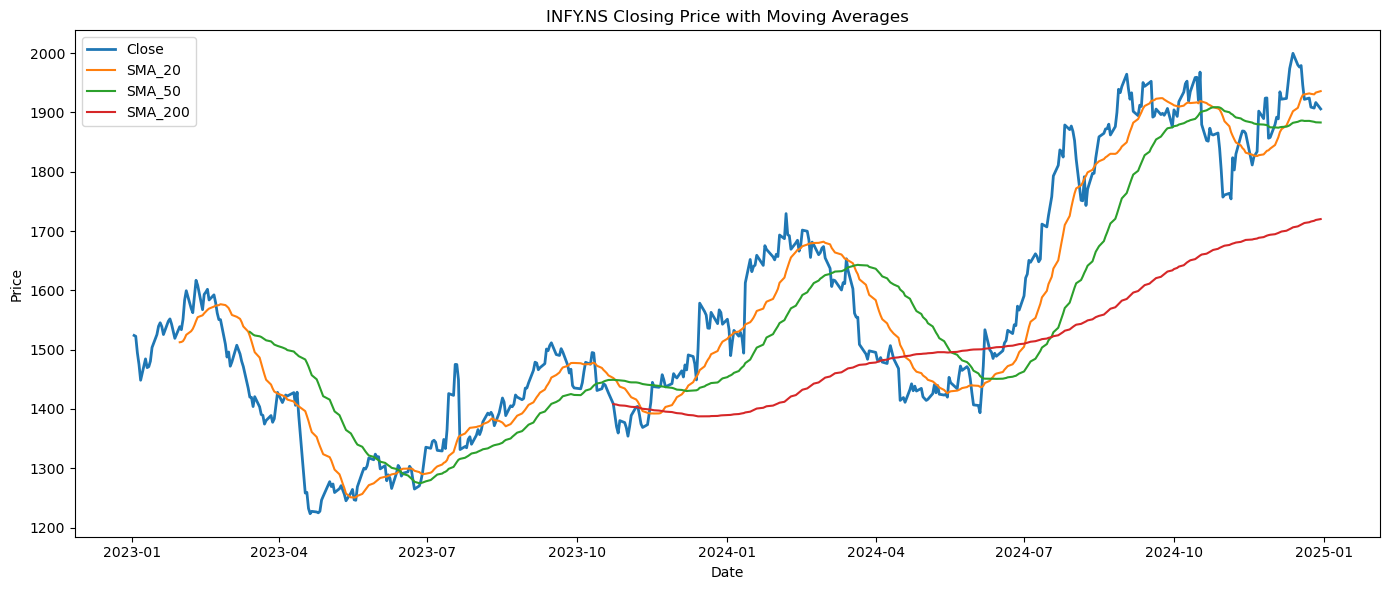

In [12]:
# 1) Close + Moving Averages
plt.figure(figsize=(14,6))
plt.plot(df_ind.index, df_ind["Close"], label="Close", linewidth=2)
for w in [20, 50, 200]:
    plt.plot(df_ind.index, df_ind[f"SMA_{w}"], label=f"SMA_{w}")
plt.title(f"{ticker} Closing Price with Moving Averages")
plt.xlabel("Date")
plt.ylabel("Price")
plt.legend()
plt.tight_layout()
plt.savefig(images_dir / f"{ticker}_moving_averages.png", dpi=150)
plt.show()  
plt.close()

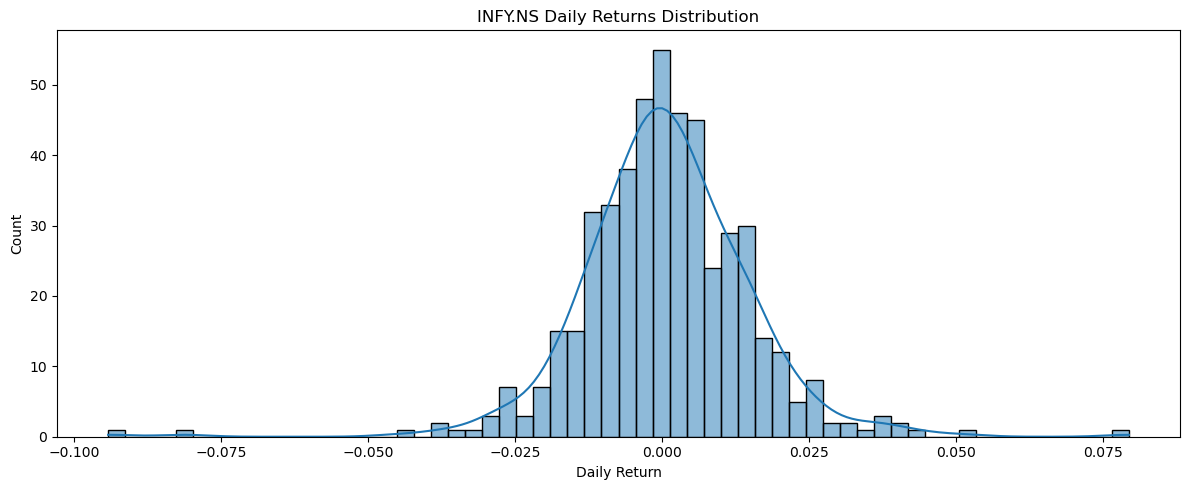

In [13]:
# 2) Returns distribution
plt.figure(figsize=(12,5))
sns.histplot(df_ind["Daily_Return"].dropna(), bins=60, kde=True)
plt.title(f"{ticker} Daily Returns Distribution")
plt.xlabel("Daily Return")
plt.tight_layout()
plt.savefig(images_dir / f"{ticker}_returns_distribution.png", dpi=150)
plt.show()  
plt.close()

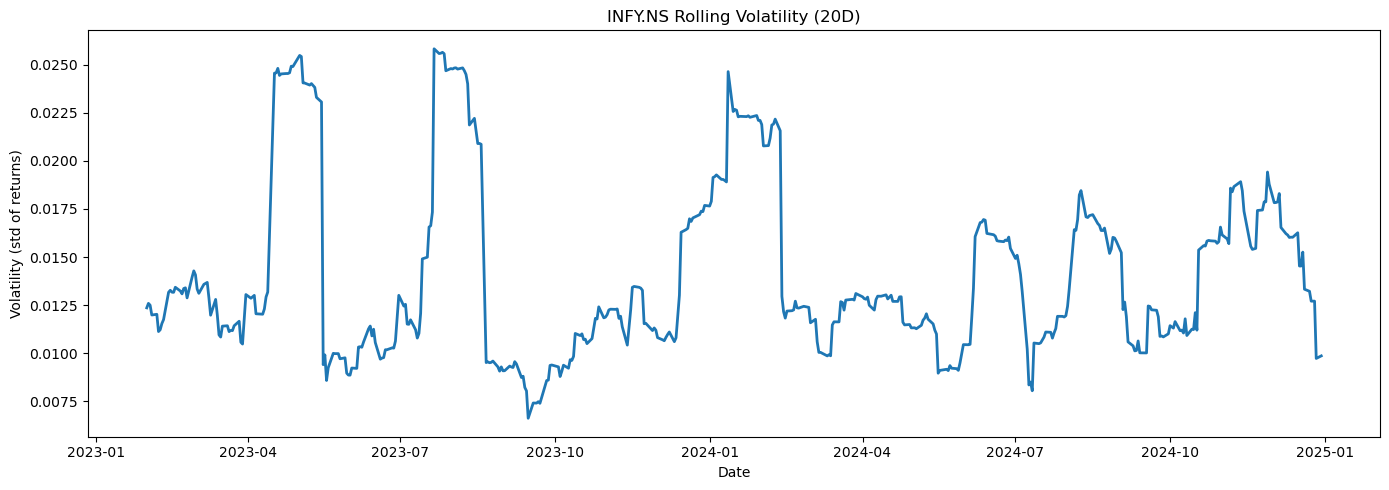

In [14]:
# 3) Rolling volatility
plt.figure(figsize=(14,5))
plt.plot(df_ind.index, df_ind["Volatility_20"], linewidth=2)
plt.title(f"{ticker} Rolling Volatility (20D)")
plt.xlabel("Date")
plt.ylabel("Volatility (std of returns)")
plt.tight_layout()
plt.savefig(images_dir / f"{ticker}_volatility.png", dpi=150)
plt.show() 
plt.close()

In [15]:
from pathlib import Path

outputs_dir = PROJECT_ROOT / "outputs"
images_dir = PROJECT_ROOT / "images"

outputs_dir.mkdir(parents=True, exist_ok=True)
images_dir.mkdir(parents=True, exist_ok=True)

# Save cleaned+indicators CSV
df_ind.to_csv(outputs_dir / f"{ticker}_cleaned_with_indicators.csv")